Mounted at /content/drive


Saving phonic-chemist-509603-v9-6d0523a7b77d.json to phonic-chemist-509603-v9-6d0523a7b77d.json
Connected to project: phonic-chemist-509603-v9
(819, 4)


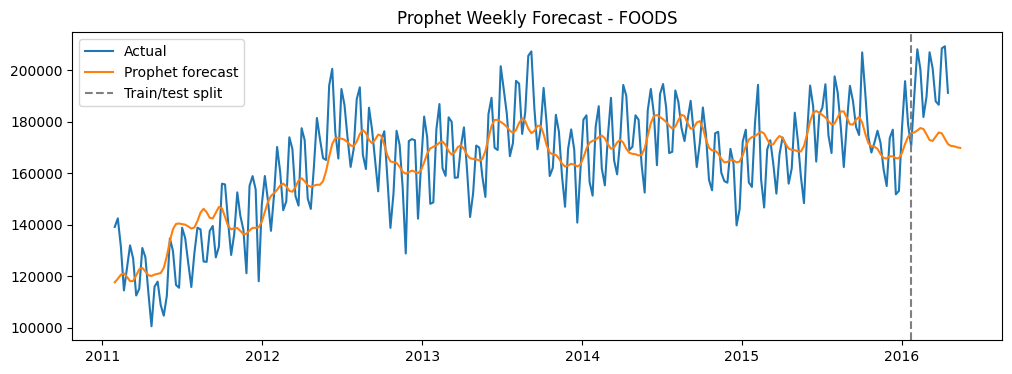

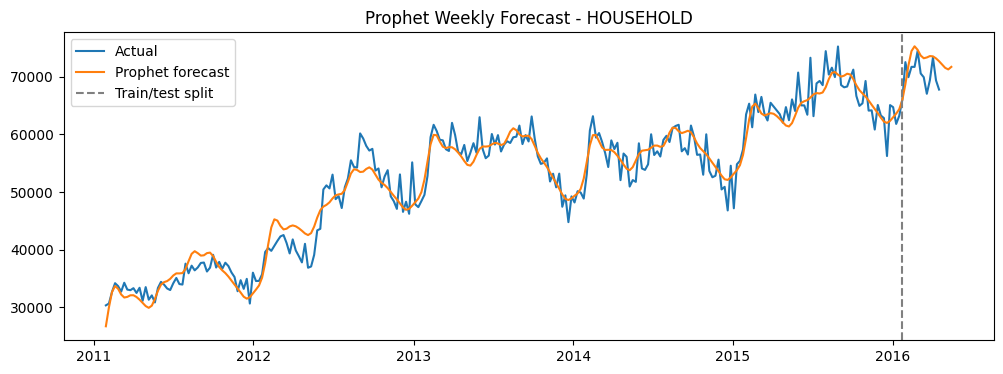

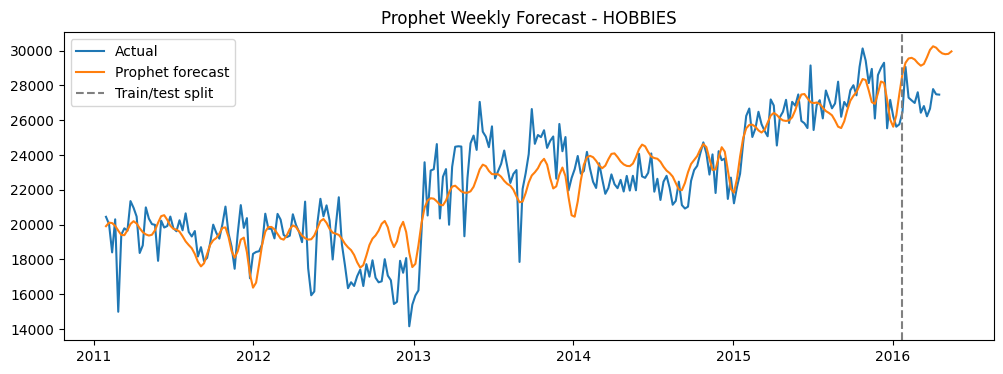

      cat_id      MAE   WMAPE
0      FOODS  21936.0  0.1115
1  HOUSEHOLD   3189.0  0.0451
2    HOBBIES   2387.0  0.0876
Saved prophet_forecasts.csv (831, 5)


In [1]:
!pip install prophet -q

from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
uploaded = files.upload()

from google.cloud import bigquery
client = bigquery.Client.from_service_account_json(list(uploaded.keys())[0])
print("Connected to project:", client.project)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

# ---- 1. Pull weekly mart + week start dates from BigQuery ----
query = """
SELECT w.wm_yr_wk, c.week_start, w.cat_id, SUM(w.total_units_sold) AS units
FROM `phonic-chemist-509603-v9.m5_analytics.mart_weekly_sales` w
JOIN (
    SELECT wm_yr_wk, MIN(date) AS week_start
    FROM `phonic-chemist-509603-v9.m5_raw.calendar`
    GROUP BY wm_yr_wk
) c ON w.wm_yr_wk = c.wm_yr_wk
GROUP BY w.wm_yr_wk, c.week_start, w.cat_id
ORDER BY c.week_start
"""
df = client.query(query).to_dataframe()
df["week_start"] = pd.to_datetime(df["week_start"])
df = df[df["week_start"] < df["week_start"].max()]  # drop last partial week
print(df.shape)

# ---- 2. Train/test split: hold out last 12 weeks ----
HOLDOUT = 12
results = []
all_forecasts = []

for cat in df["cat_id"].unique():
    s = df[df["cat_id"] == cat][["week_start", "units"]].rename(columns={"week_start": "ds", "units": "y"})
    train, test = s.iloc[:-HOLDOUT], s.iloc[-HOLDOUT:]

    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(train)

    future = m.make_future_dataframe(periods=HOLDOUT + 4, freq="W-SAT")
    fc = m.predict(future)[["ds", "yhat", "yhat_lower", "yhat_upper"]]
    fc["cat_id"] = cat
    all_forecasts.append(fc)

    pred = fc.set_index("ds").loc[test["ds"], "yhat"].values
    mae = np.mean(np.abs(test["y"].values - pred))
    wmape = np.sum(np.abs(test["y"].values - pred)) / np.sum(test["y"].values)
    results.append({"cat_id": cat, "MAE": round(mae, 1), "WMAPE": round(wmape, 4)})

    plt.figure(figsize=(12, 4))
    plt.plot(s["ds"], s["y"], label="Actual")
    plt.plot(fc["ds"], fc["yhat"], label="Prophet forecast")
    plt.axvline(train["ds"].iloc[-1], color="gray", linestyle="--", label="Train/test split")
    plt.title(f"Prophet Weekly Forecast - {cat}")
    plt.legend()
    plt.savefig(f"prophet_{cat}.png", dpi=150, bbox_inches="tight")
    plt.show()

print(pd.DataFrame(results))

prophet_forecasts = pd.concat(all_forecasts)
prophet_forecasts.to_csv("prophet_forecasts.csv", index=False)
print("Saved prophet_forecasts.csv", prophet_forecasts.shape)